# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [10]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [11]:
monthly_mean = df['count'].resample('ME').mean()
monthly_mean.head()

,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211


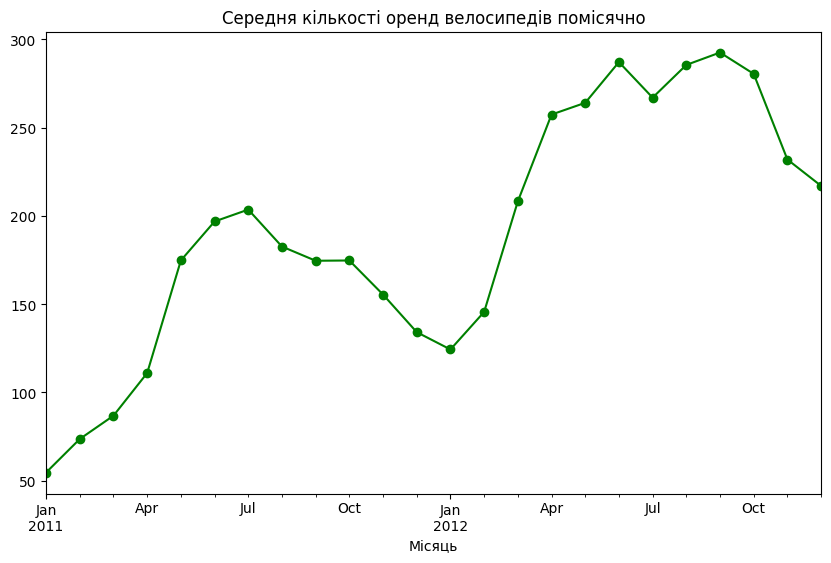

In [90]:
monthly_mean.plot(
    marker='o',
    figsize=(10, 6),
    title='Середня кількості оренд велосипедів помісячно',
    xlabel='Місяць',
    color='green'
);

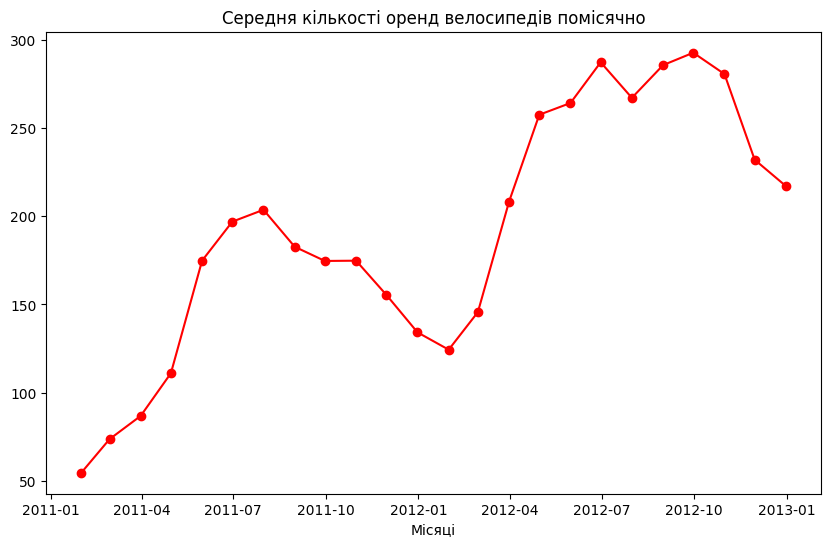

In [91]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_mean, 'o-r')
plt.title('Середня кількості оренд велосипедів помісячно')
plt.xlabel('Місяці')
plt.show();

Мені більше подобається другий графік, і саме тим, чим він відрізняється: сам графік не торкається осей і інший формат підпису місяців по осі х.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [14]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

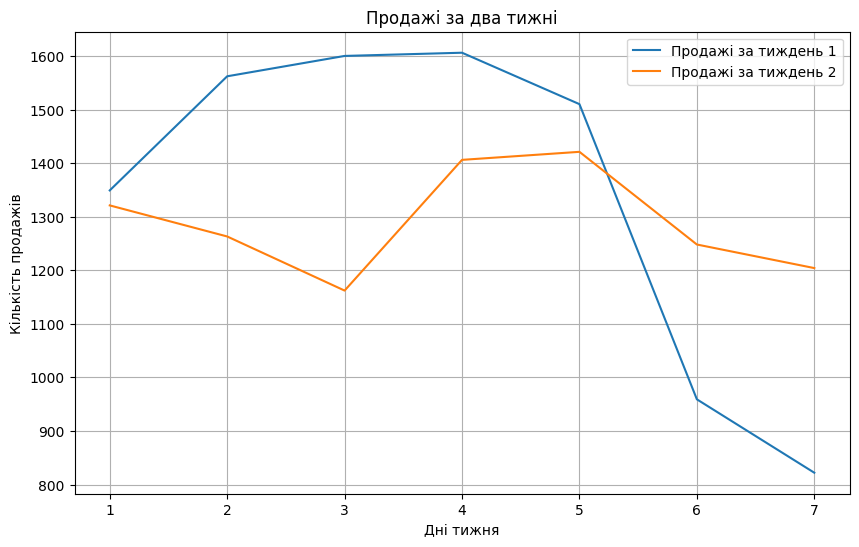

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(days, sales_week1, label='Продажі за тиждень 1')
plt.plot(days, sales_week2, label='Продажі за тиждень 2')

plt.title('Продажі за два тижні')
plt.xlabel('Дні тижня')
plt.ylabel('Кількість продажів')
plt.grid(True)
plt.legend()
plt.show()

Більш стабільні продажі буди у другий тиждень (на графіку помаранчева лінія). Дані продажів коливаються значно менше, ніж у перший тиждень.

У перший тиждень діапазон продажів від 1350 до 850, а у другий тиждень - від 1320 до 1160. Це можна підкріпити обчисленням розмаху.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [18]:
# Середня температура помісячно:

monthly_temp = df['temp'].resample('ME').mean()
monthly_temp.head()

,temp
datetime,
2011-01-31,8.633782
2011-02-28,11.331076
2011-03-31,14.063184
2011-04-30,17.776879
2011-05-31,21.528596


In [20]:
#  Середня годинна кількість оренд за кварталами

hour_count_mean = df['count'].resample('QE').mean()
hour_count_mean

,count
datetime,
2011-03-31,71.905518
2011-06-30,160.940746
2011-09-30,186.994872
2011-12-31,154.787125
2012-03-31,159.476889
2012-06-30,269.601757
2012-09-30,281.735380
2012-12-31,243.189466


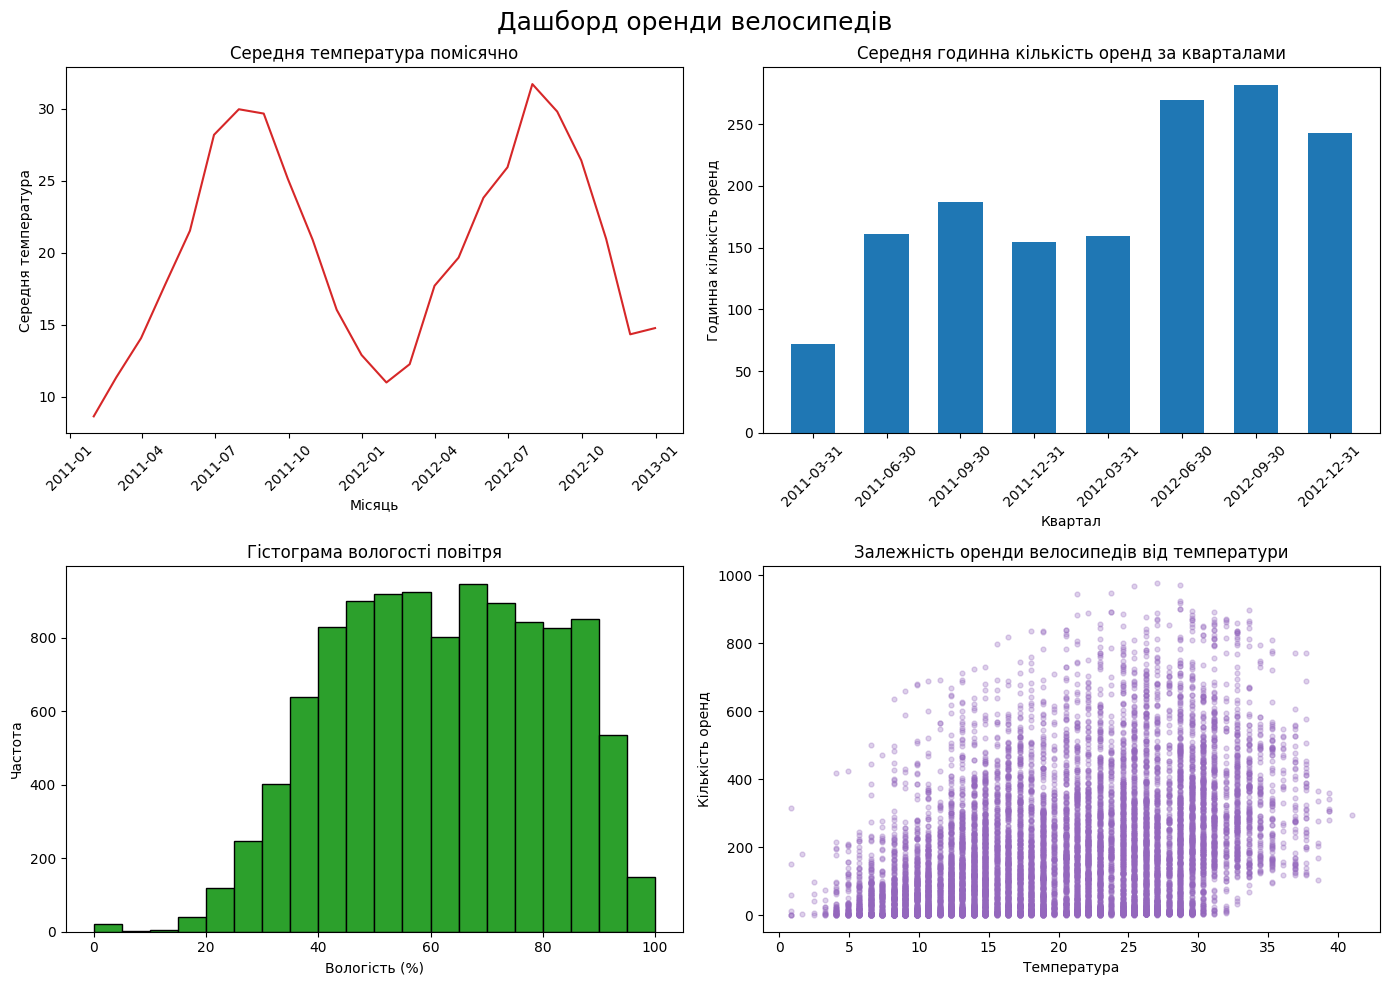

In [39]:
plt.figure(figsize=(14, 10))
plt.suptitle('Дашборд оренди велосипедів', fontsize=18)

plt.subplot(2, 2, 1)
plt.plot(monthly_temp, color='tab:red')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Середня температура')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
plt.bar(hour_count_mean.index.astype(str), hour_count_mean.values, color='tab:blue', width=0.6)
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Годинна кількість оренд')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='tab:green', edgecolor='black')           # Параметр bins=20 розбиває весь діапазон вологості (від 0% до 100%) на 20 однакових інтервалів
plt.title('Гістограма вологості повітря')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')                                                             # Висота стовпчика показує, скільки саме погодинних вимірів у датасеті мали вологість
                                                                                  # у межах цього конкретного інтервалу.
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.3, color='tab:purple', s=12)         # s — скорочення від size (площа марки/точки)
plt.title('Залежність оренди велосипедів від температури')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')

plt.tight_layout()                                                                # Вирівнює відступи між графіками
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

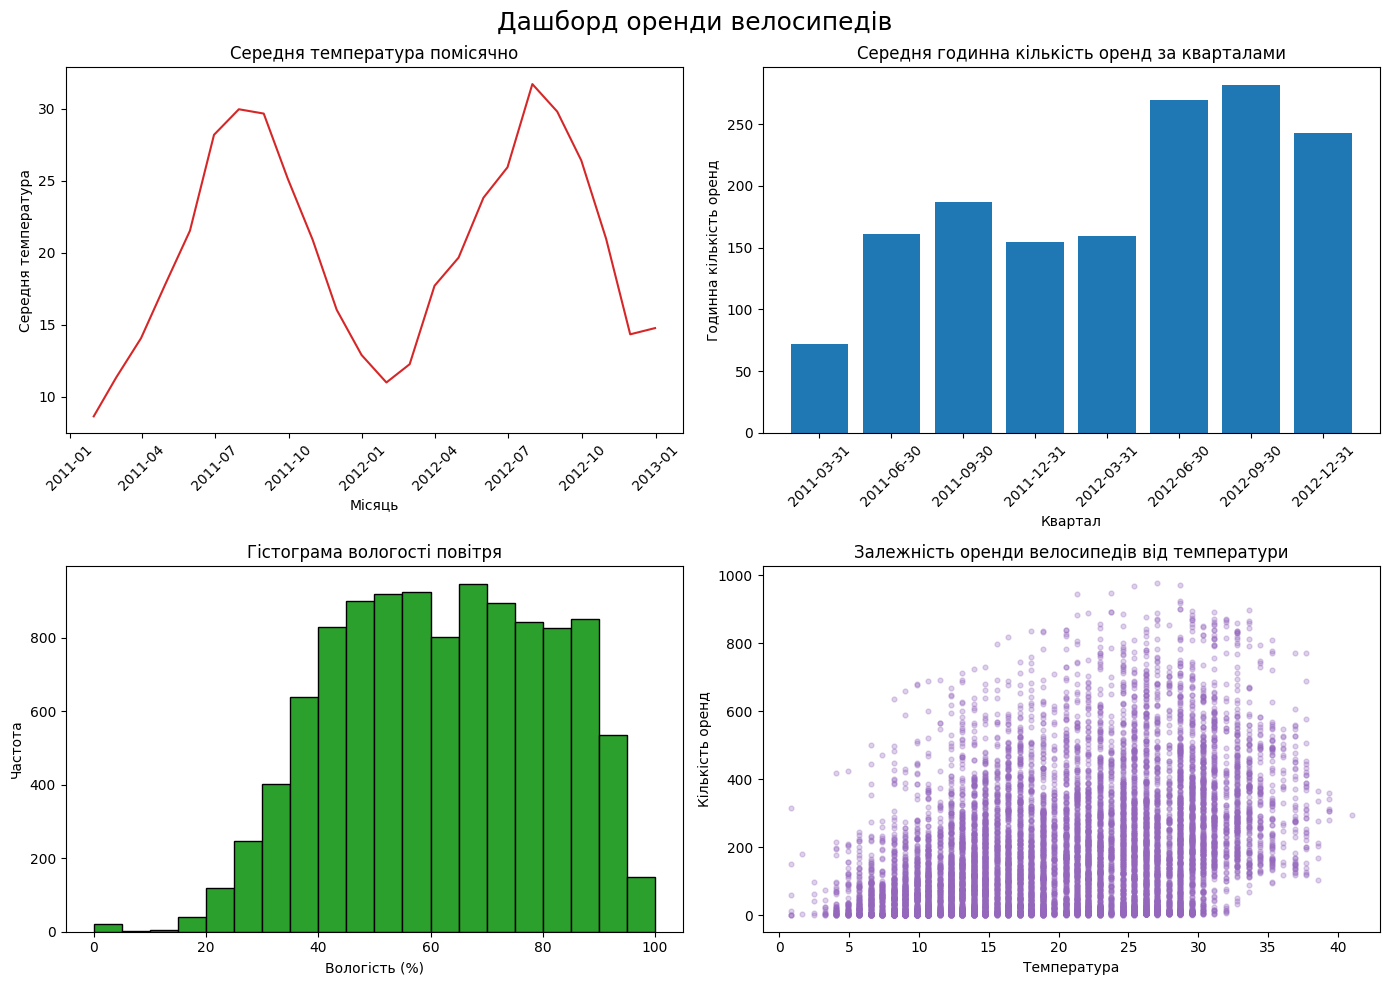

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Дашборд оренди велосипедів', fontsize=18)

# 1. Лінійний графік середньої температури помісячно (верхній лівий)
ax[0, 0].plot(monthly_temp, color='tab:red')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Середня температура')
ax[0, 0].tick_params(axis='x', rotation=45)

# 2. Графік середньої годинної кількості оренд за кварталами (верхній правий)
ax[0, 1].bar(hour_count_mean.index.astype(str), hour_count_mean.values)
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Годинна кількість оренд')
ax[0, 1].tick_params(axis='x', rotation=45)

# 3. Гістограма вологості повітря (нижній лівий)
ax[1, 0].hist(df['humidity'], bins=20, color='tab:green', edgecolor='black')
ax[1, 0].set_title('Гістограма вологості повітря')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота')

# 4. Scatter plot температури vs кількості оренд (нижній правий)
ax[1, 1].scatter(df['temp'], df['count'], alpha=0.3, color='tab:purple', s=12)
ax[1, 1].set_title('Залежність оренди велосипедів від температури')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

Як на мене, результат в обох підходах вийшов ідентичним. Але у другому варанті треба писати більше коду, оскільки для кожного графіка потрібно звертатись до ах у кожному рядочку кода (до кожної комірки загального дашборду).

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [46]:
monthly_count = df['count'].resample('ME').agg(['mean', 'max', 'min'])
monthly_count.head()

,mean,max,min
datetime,,,
2011-01-31,54.645012,219,1
2011-02-28,73.641256,327,1
2011-03-31,86.849776,332,1
2011-04-30,111.026374,452,1
2011-05-31,174.809211,611,1


In [85]:
import matplotlib.dates as mdates

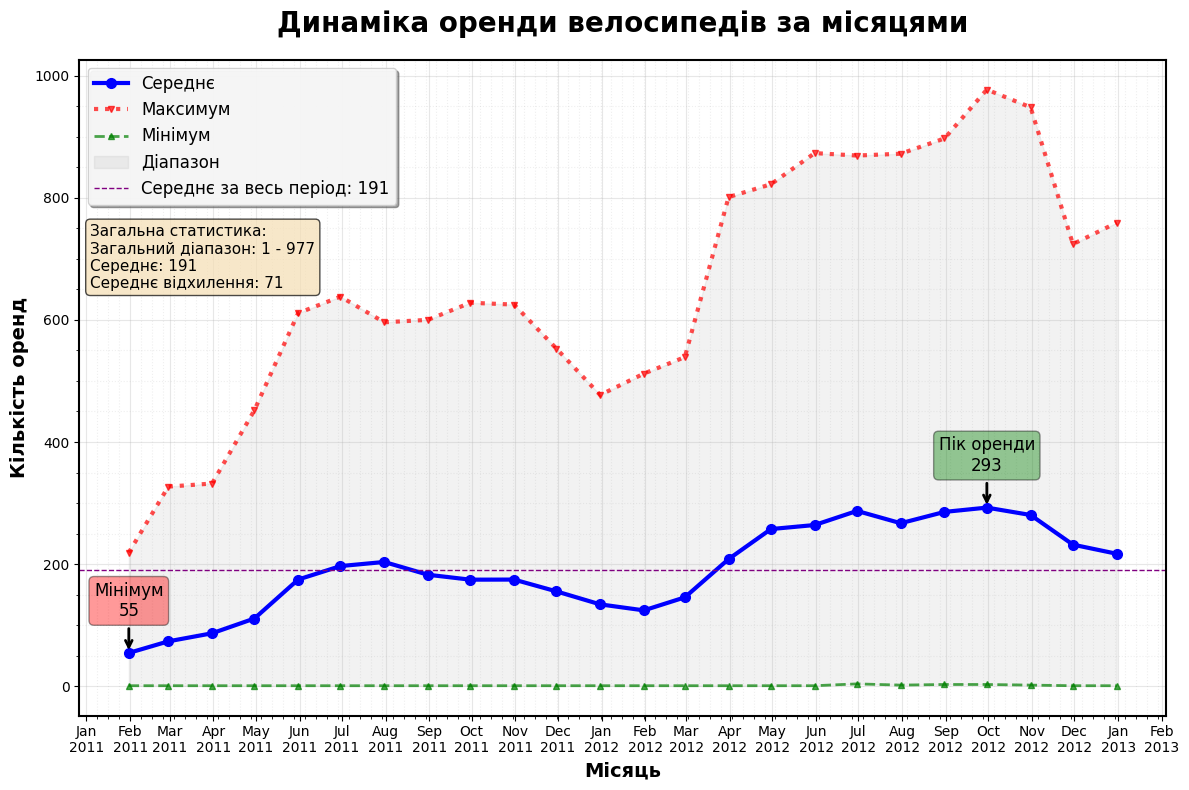

In [89]:
# Створюємо фігуру і три лінії: середнє, максимум, мінімум за місяцями
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(monthly_count.index, monthly_count['mean'], 'b-o', linewidth=3, label='Середнє', markersize=7)
ax.plot(monthly_count.index, monthly_count['max'], 'r:v', linewidth=3, label='Максимум', markersize=5, alpha=0.7)
ax.plot(monthly_count.index, monthly_count['min'], 'g--^', linewidth=2, label='Мінімум', markersize=5, alpha=0.7)

# Заливка області між мінімумом та максимумом
ax.fill_between(monthly_count.index, monthly_count['min'], monthly_count['max'],
                alpha=0.1, color='gray', label='Діапазон')

# Дві анотації: для найвищого та найнижчого середнього значення
max_idx = monthly_count['mean'].idxmax()
max_val = monthly_count['mean'].max()
ax.annotate(f'Пік оренди\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 60),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='green', alpha=0.4))

min_idx = monthly_count['mean'].idxmin()
min_val = monthly_count['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}',
            xy=(min_idx, min_val), xytext=(min_idx, min_val + 60),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.4))

# Горизонтальна лінія середнього за весь рік
overall_mean = monthly_mean.mean()
ax.axhline(y=overall_mean, color='purple', linestyle='--', linewidth=1,
           label=f'Середнє за весь період: {overall_mean:.0f}')

# Двошарова сітка: основна та допоміжна
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Стилізована легенда з тінню
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Текстовий блок зі статистикою в кутку графіка
textstr = 'Загальна статистика:\n'
textstr += f'Загальний діапазон: {monthly_count["min"].min():.0f} - {monthly_count["max"].max():.0f}\n'
textstr += f'Середнє: {monthly_count['mean'].mean():.0f}\n'
textstr += f'Середнє відхилення: {monthly_count['mean'].std():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
ax.text(0.01, 0.75, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Оформлення: заголовки, підписи осей з жирним шрифтом
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=14, fontweight='bold')
ax.set_title('Динаміка оренди велосипедів за місяцями', fontsize=20, fontweight='bold', pad=20)

# Форматування дат на осі X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


Питання для інтерпретації:

1. Яка перевага додавання анотацій на графік?

Це допомагає звернути увагу на важливі цифри, щоб їх було видно одразу на графіку, без потреби дивитись у таблички.

2. Для чого використовується fill_between()?

Для позначення діапазону значень. Так візуально краще сприймається площа значень.

3. Як текстовий блок допомагає в інтерпретації даних?

Легенда.
